In [114]:
##### Josie Pettis #####
#  OBAN Assignment 2
#  Due: October 2,2026

"""
Created By    : Jared W. Marquis
Creation Date : 01 August 2022
Course        : ATSC 528-Atmospheric Data Analysis
Assignment    : #01-Function Fitting

Purpose:
Script to take sparse upper air observations and analyze them on a
polar stereographic map projection using function fitting.
[PUT MORE INFORMATION HERE-I.E.,WHAT SPECIFIC THING IS BEING DONE]

"""
__author__   ="Jared W. Marquis"
__contact__  ="jared.marquis@und.edu"

In [115]:
### Import Required Modules (shouldn't need to change) ###
import numpy as np                 #numpy for math
import matplotlib.pyplot as plt    #matplotlib for plotting
import cartopy.crs as ccrs         #cartopy for plotting on map
import cartopy.feature as cfeature #cartopy basic shapefiles
import pandas as pd

In [116]:
### Read in observations ### 

# --- Question 1 ---- #
name=['Station ID','Latitude','Longitude','500mb Height (m)','500mb Wind Direction','500mb Wind Speed (kt)'] #create column names
df=pd.read_csv('RAOBs_201903131200.txt',sep=',',header=None,names=name) #i am utilizing Pandas to read in the text file,so I added it to the Modules.

# --- Question 2 ---- #
phi_0=np.radians(60)
lambda_0=-100
m=1/15000000
rho=6371 * 1e3 #calculate via SI units

print(df)

    Station ID  Latitude  Longitude  500mb Height (m)  500mb Wind Direction  \
0         CWPL     51.47      -90.2            5460.0                 285.0   
1         CWQI     43.83      -66.0            5540.0                 325.0   
2         CWSE     53.55     -113.9            5360.0                 280.0   
3         CYAH     53.75      -73.6            5340.0                 300.0   
4         CYBK     64.30      -96.0            5220.0                  95.0   
..         ...       ...        ...               ...                   ...   
130       KWAL     37.93      -75.4            5730.0                 325.0   
131       KXKF     32.37      -64.6            5620.0                 300.0   
132       KYAK     59.52     -139.6            5340.0                 195.0   
133       KYMW     46.38      -75.9            5580.0                 275.0   
134       KYXY     60.72     -135.0            5340.0                 300.0   

     500mb Wind Speed (kt)  
0                     

In [117]:
### Set up analysis map with a 21x27 rectangular grid of points ###

# --- Question 3 ----#

#from the assignment
mX,mY=21,27 # x (N to S) and y (W to E)
dx=dy=1.27 #cm
xo,yo=25,-15.5 #cm

# x increases to the south y increases eastward.
x_fix=xo+dx * np.arange(mX)
y_fix=yo+dy * np.arange(mY)
x_cm,y_cm=np.meshgrid(x_fix,y_fix,indexing='ij')   # shape 21x27

x=x_cm / 100.0 / m   # map cm onto image plane
y=y_cm / 100.0 / m
psi0=np.pi / 2-phi_0  # co-latitude
r=np.sqrt(x**2+y**2) # calculate using distance eqn
phi=np.pi / 2-2.0 * np.arctan(r / (rho * (1.0+np.cos(psi0)))) #from the notes
lam=np.arctan2(y,x) # lambda=lon-lam0 (east positive)
lat=np.degrees(phi)
lon=(lambda_0+np.degrees(lam)+180.0) % 360.0-180.0
       # each has shape 21x27,which will be verified in next step

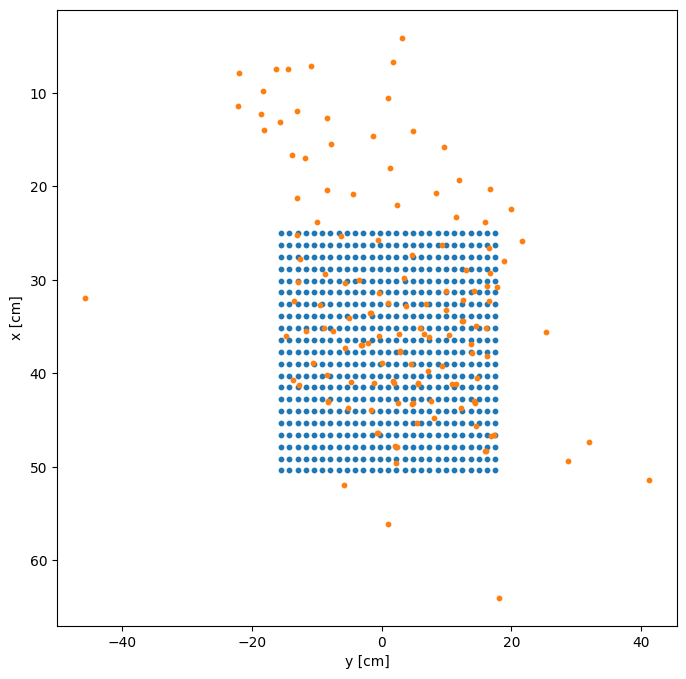

In [118]:
### convert obs lat/long to x,y (may want to plot on your analysis grid to verify)###
phi=np.radians(df['Latitude'].values)
lam=np.radians(df['Longitude'].values-lambda_0) #east positive
sigma=(1.0+np.sin(phi_0)) / (1.0+np.sin(phi)) # calculating sigma/scale factor
R=m * sigma * rho * np.cos(phi) # creates radius of lat circle found in notes
df['x_cm']=100.0 * R * np.cos(lam) # x should theoretically increases southward IN CENTIMETERS
df['y_cm']=100.0 * R * np.sin(lam) # y should theoretically increases eastward IN CENTIMETERS


# Verification plot: obs on the analysis grid,in map coordinates
fig,ax=plt.subplots(figsize=(8,8))
ax.scatter(y_cm,x_cm,s=10)
ax.scatter(df['y_cm'],df['x_cm'],s=10)
ax.set_xlabel('y [cm]')
ax.set_ylabel('x [cm]')
ax.invert_yaxis()
plt.show()

# I counted 21x27 in the grid below,so this verifies the code holds true.

In [119]:
### Perform 500mb geopotential height analyses using a second order 2-d polynomial with two ###
### radii of influence (10cm & 20cm & 6cm *not required*) ###
RoI_list=[10.0,20.0,6.0]   
X,Y=x_cm,y_cm #analysis grid (cm),from Q3
nx,ny=X.shape #21x27

obs_x=df['x_cm'].values #observation locations [cm]
obs_y=df['y_cm'].values
obs_z=df['500mb Height (m)'].values
ANALYSIS=np.full((nx,ny,len(RoI_list)),np.nan) #analysis value at each point using RoI
OBSERVATION=np.zeros((nx,ny,len(RoI_list)),dtype=int) #obs value used at each point using RoI

for r,RoI in enumerate(RoI_list):
    for i in range(nx):
        for j in range(ny):
            xi,yi=X[i,j],Y[i,j] #this "point" specifically for the ROI^^
            dxk=obs_x-xi #deviations of every ob from the analysis point in x direction
            dyk=obs_y-yi #same thing, but y direction... defining these will help later when finding the internal obs.
            dist=np.sqrt((obs_x-xi)**2+(obs_y-yi)**2) #defines the distances within ROI deviation of obs to analysis point
            inside=dist<=RoI #obs within the RoI selection
            n=inside.sum() #sums together the obs
            OBSERVATION[i,j,r]=n #creates the massive matrix x,y,z required to solve coefficients
            xk=dxk[inside] #deviation on the x axis inside the ROI
            yk=dyk[inside] #deviation on the y axis inside the ROI
            fk=obs_z[inside] #deviation for the heights inside the ROI
            #format matrix, like row one [1,x,y,x^2,y^2,xy] per ob (N=2 polynomial terms)
            dlf=np.column_stack([np.ones_like(xk),xk,yk,xk**2,yk**2,xk * yk])
            # "mean" form in the notes,since dividing both sides by n cancels
            # each entry is the mean over the k obs inside the RoI...
            A = (dlf.T @ dlf) / n
            b = (dlf.T @ fk) / n
            c=np.linalg.solve(A,b) #Calculating our coeff! Thank you numpy for some of the best features to save me time :)

            ANALYSIS[i,j,r]=c[0] # c00=f(xi,yi),since xk,yk are deviations

            #This matrix killed me inside, hopefully my comments make sense, if they don't i can explain them a different way

#To confirm if this wonderful matrix worked... we will verify our points through heights provided in class
## IN A NUTSHELL column 1=x coord -1, column 2=y coord -1, column 3 = roi selection

#ROI 10 
print(ANALYSIS[0,0,0]) #furthest pt to the top left corner
print(ANALYSIS[20,26,0]) #furthest pt to the bottom right corner

#ROI 20
print(ANALYSIS[0,0,1]) #furthest pt to the top left corner
print(ANALYSIS[20,26,1]) #furthest pt to the bottom right corner

#Thank goodness, I would have cried. I had to eat 4 sides of Mozz sticks to get through this code. WHY IS THERE A WARNING??? IS IT BC
# OF THE LACK OF COEFF???

5556.722360174691
5884.01423439493
5409.974966395672
5922.709979299014


/var/folders/bw/m5xz880x3qdd4ckh33wkrvr80000gn/T/ipykernel_68497/2365607818.py:30: RuntimeWarning: invalid value encountered in divide
  A = (dlf.T @ dlf) / n
/var/folders/bw/m5xz880x3qdd4ckh33wkrvr80000gn/T/ipykernel_68497/2365607818.py:31: RuntimeWarning: invalid value encountered in divide
  b = (dlf.T @ fk) / n


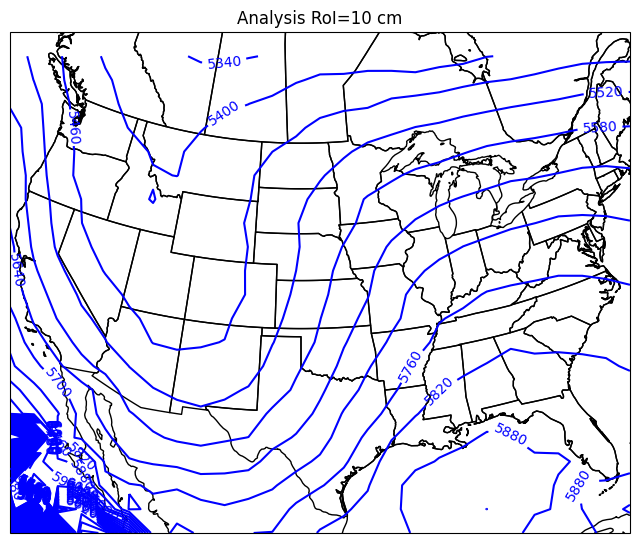

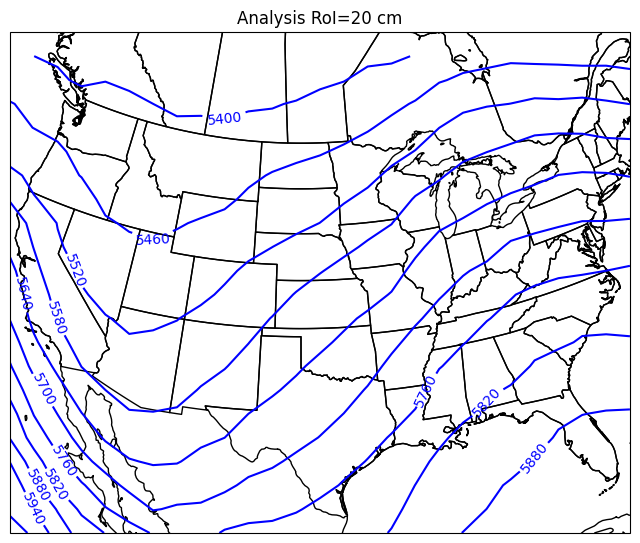

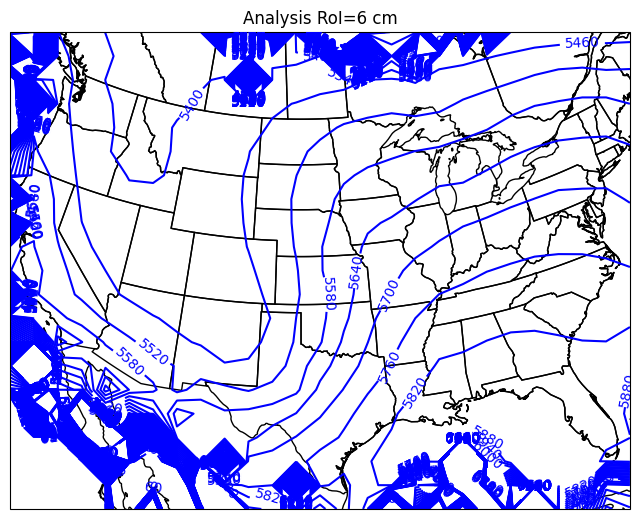

In [120]:
### Plot 500mb analyses over a map ###
globe=ccrs.Globe(ellipse=None,semimajor_axis=rho,semiminor_axis=rho) #I removed the /100 because it was giving me a wacky grid and it didn't align with my conversion units. It was easier deleting it than going through and figuring out what was/wasn't in the correct units
proj=ccrs.Stereographic(central_longitude=lambda_0,central_latitude=90,true_scale_latitude=phi_0,globe=globe) #only use this for the axis feature,the other required the use of globe for some reason..? I kept getting errors telling me it was a transform issue.

# plot analysis (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
#RoI: 10cm
fig=plt.figure(figsize=(8,8))
ax1=fig.add_subplot(111,projection=proj)
ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
cs1=ax1.contour(lon,lat,ANALYSIS[:,:,0],colors='b',levels=np.arange(0,8000,60),transform=ccrs.PlateCarree(globe=globe))
plt.clabel(cs1,levels=np.arange(0,8000,60))
ax1.set_title('Analysis RoI=10 cm')
plt.savefig('analysis_RoI10cm.png')
plt.show()

#RoI: 20cm
fig=plt.figure(figsize=(8,8))
ax2=fig.add_subplot(111,projection=proj)
ax2.add_feature(cfeature.STATES)
ax2.add_feature(cfeature.COASTLINE)
cs2=ax2.contour(lon,lat,ANALYSIS[:,:,1],colors='b',levels=np.arange(0,8000,60),transform=ccrs.PlateCarree(globe=globe))
plt.clabel(cs2,levels=np.arange(0,8000,60))
ax2.set_title('Analysis RoI=20 cm')
plt.savefig('analysis_RoI20cm.png')
plt.show()

#ROI: 6cm
fig=plt.figure(figsize=(8,8))
ax3=fig.add_subplot(111,projection=proj)
ax3.add_feature(cfeature.STATES)
ax3.add_feature(cfeature.COASTLINE)
cs3=ax3.contour(lon,lat,ANALYSIS[:,:,2],colors='b',levels=np.arange(0,8000,60),transform=ccrs.PlateCarree(globe=globe))
plt.clabel(cs3,levels=np.arange(0,8000,60))
ax3.set_title('Analysis RoI=6 cm')
plt.show()

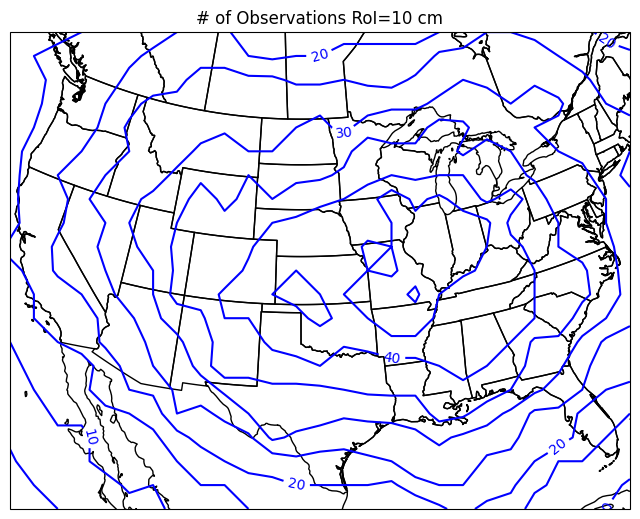

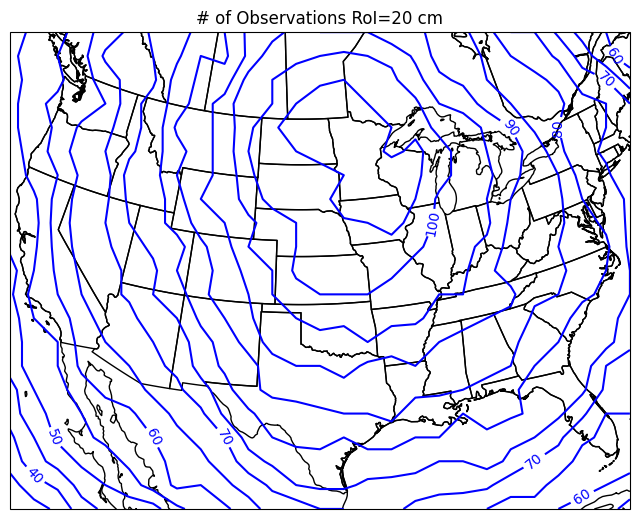

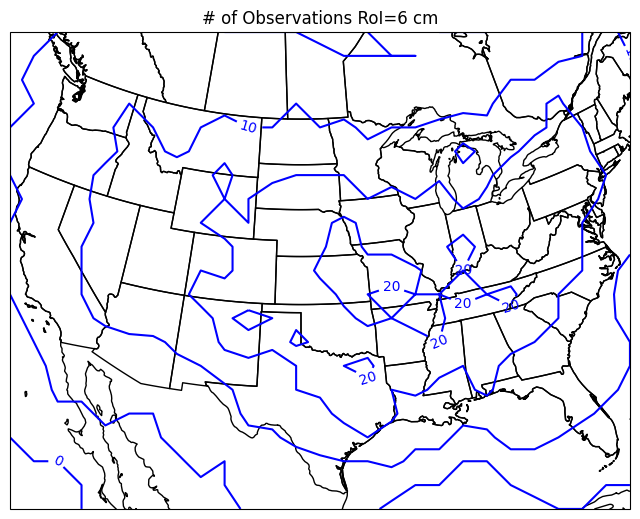

In [121]:
### Plot number of observations available to polynomial fitting scheme for each grid point ###
globe=ccrs.Globe(ellipse=None,semimajor_axis=rho,semiminor_axis=rho) #same idea as the analysis.
proj=ccrs.Stereographic(central_longitude=lambda_0,central_latitude=90,true_scale_latitude=np.degrees(phi_0),globe=globe) #same idea as analysis

# plot number of observations (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #

#ROI: 10cm
fig= plt.figure(figsize=(8,8))
ax1=fig.add_subplot(111,projection=proj)
ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
cs1=ax1.contour(lon,lat,OBSERVATION[:,:,0],colors='b',levels=np.arange(0,200,5),transform=ccrs.PlateCarree(globe=globe))
plt.clabel(cs1,levels=np.arange(0,200,10))
ax1.set_title('# of Observations RoI=10 cm')
plt.savefig('observation_RoI10cm.png')
plt.show()

#ROI: 20cm
fig=plt.figure(figsize=(8,8))
ax2=fig.add_subplot(111,projection=proj)
ax2.add_feature(cfeature.STATES)
ax2.add_feature(cfeature.COASTLINE)
cs2=ax2.contour(lon,lat,OBSERVATION[:,:,1],colors='b',levels=np.arange(0,200,5),transform=ccrs.PlateCarree(globe=globe))
plt.clabel(cs2,levels=np.arange(0,200,10))
ax2.set_title('# of Observations RoI=20 cm')
plt.savefig('observation_RoI20cm.png')
plt.show()

#ROI: 6 cm (not required to show in the assignment)
fig=plt.figure(figsize=(8,8))
ax3=fig.add_subplot(111,projection=proj)
ax3.add_feature(cfeature.STATES)
ax3.add_feature(cfeature.COASTLINE)
cs3=ax3.contour(lon,lat,OBSERVATION[:,:,2],colors='b',levels=np.arange(0,200,5),transform=ccrs.PlateCarree(globe=globe))
plt.clabel(cs3,levels=np.arange(0,200,10))
ax3.set_title('# of Observations RoI=6 cm')
plt.show()

In [122]:
### Store the analyses in text files ###
for r,RoI in enumerate(RoI_list):
    out=np.column_stack([np.repeat(np.arange(nx),ny),np.tile(np.arange(ny),nx),x_cm.ravel(),y_cm.ravel(),lat.ravel(),lon.ravel(),ANALYSIS[:,:,r].ravel(),OBSERVATION[:,:,r].ravel()])

    fname=f'analysis_cm.txt'
    np.savetxt(fname,out,header='i j x_cm y_cm lat lon height_m Observations',fmt=['%d','%d','%.4f','%.4f','%.4f','%.4f','%.4f','%d'])

In [123]:
### Store the number of observations available for each grid point in text files ###
for r,RoI in enumerate(RoI_list):
    out=np.column_stack([np.repeat(np.arange(nx),ny),np.tile(np.arange(ny),nx),x_cm.ravel(),y_cm.ravel(),lat.ravel(),lon.ravel(),OBSERVATION[:,:,r].ravel()])

    fname=f'obs_cm.txt'
    np.savetxt(fname,out,header='i j x_cm y_cm lat lon Observations',fmt=['%d','%d','%.4f','%.4f','%.4f','%.4f','%d'])

In [124]:
### In a separte text file (or below),answer the following questions ###
'''
1-Describe the general features that you see in your contoured analyses.
    Some things I noticed on the analysis is that ROI has a major influence on the plots (discussed in #2). For instance, in the 10cm ROI
    I saw a lot of different features that weren't smoothed over including the tear drop shape in Idaho, the dot in the Gulf, and the 
    multiple isoheights in the southwest corner. I saw these were mostly smoothed in the 20cm ROI and overall looked like a typical 500mb 
    Map Analysis. Another key feature I noticed was the placement of the trough. In the 10cm, it appears more squished and narrow near
    Arizona and New Mexico, but compared to the 20cm ROI, the trough is wider and spans across multiple western states. We also notice that
    the ridge pattern in the southeast is more smooth.

2-Describe the differences that you see in your contoured analyses.  
    Does one analysis seem to be smoother than the other?  If so,what would cause this?
   
    Analysis Charts: With an ROI of 10cm, we tend to see 500mb features that aren't as smooth as the 20cm. For instance, looking on the southwest
    part of the map, it is evident that there is multiple contours on the 10cm chart, which could signify a smoothing issue considering our
    radius of influence is smaller. Since the radius of influence is smaller, this limits the total amount of data points utilized. Another
    key feature I noticed was the spatial displacement between 10cm and 20cm ROI charts. Specifically, on the 10cm chart, looking at the Gulf
    of Mexico we can see a circular like 5880m contour, but when we compare to the 20cm, we see that same 5880m contour smoothed over Florida.
    This goes back to my original discussion regarding how the ROI impacts the total amount of points used in the smoothing process. In 
    this case, we see that an ROI of 20cm provides a more smooth overlay of contours than 10cm. Finally, looking at the main feature (the
    trough near the central United States) we can see a huge displacement between the 10cm and 20cm chart. The 10cm spatially displaces the
    trough further south, whereas the 20cm makes it wider and crosses over multiple states. This situation can be troublesome for
    forecasters, especially near the Rockies where observations alone are difficult to obtain in the mountains.

    Observation Charts: These charts verify my discussion regarding the total observations available per ROI. Oddly enough, looking at
    the 10cm ROI, we see that the observations tend to be in smaller quantities than observed in the 20cm analysis. With the central US
    ranging at about 100 observations in the 20cm ROI, we see the 10cm ROI has much less, specifically less than 40 observations. It's 
    also worth noting that the observations in the 10cm ROI look incoherent - most observations tend to have overlapping contours, which
    can be problematic with other observations available. On the other hand, the 20cm appears to flow continuously with no disconnect 
    or overlapping.

    TLDR; Main differences in ROI 10cm and 20cm is spatial displacement and this is ultimately controlled by the ROI selection. Due to the 
    lack of observations to analyze, we see that ROI 20cm is more beneficial to interperate than 10cm considering the smoothness. 


3-Run your program using a radius of influence of 6 cm (do not need to show).  
Describe the results-do they look realistic?  If there are problems, what do you think might be causing them?
        After running the ROI of 6cm and comparing it to the others, it's evident that the results do not look realistic especially at
        boarders of the grid. Considering the heights are completely compact, indicating an unrealistic height gradient, is pure evidence
        that these results aren't realistic. I think the primary reason as mentioned before stems from the available observations in the
        radius loop. Since this is primary occuring in oceans, we can expect there to be minimal observations, hence why the contour gradient
        is drastic. We can confirm this looking at the number of observations. When generating that map, it's clear that the radius of
        influence is identifying <10 observation points near the axis, which clearly shows by the tightness of the contour lines present. This
        confirms when we look over the continent and identify that the trough is still present (specifically at this ROI). This shows that 
        the continent contains more observation points than areas with minimal accessible observation points.

4-Suppose you ran this program with a small enough radius of influence that only one
observation was available for determining a polynomial fit at a grid point.  Should
you be able to perform the matrix inversion?  Why or why not?
        Considering that only one observation was available to determine the fit at a grid point, no you would not be able to perform
        the matrix inversion. This is due to the fact we have 6 coefficients that are unknown, which requires a minimum of 6 independent
        equations to identify the coefficients. Only one point will force every "upper level term" (every term with a bar) to be applied to 
        that specific point. Every row is basically built from the products of that single observation... if this matrix becomes linearly
        dependent the determinant would be 0.. so you wouldn't be able to complete the inversion without an error.

'''

"\n1-Describe the general features that you see in your contoured analyses.\n    Some things I noticed on the analysis is that ROI has a major influence on the plots (discussed in #2). For instance, in the 10cm ROI\n    I saw a lot of different features that weren't smoothed over including the tear drop shape in Idaho, the dot in the Gulf, and the \n    multiple isoheights in the southwest corner. I saw these were mostly smoothed in the 20cm ROI and overall looked like a typical 500mb \n    Map Analysis. Another key feature I noticed was the placement of the trough. In the 10cm, it appears more squished and narrow near\n    Arizona and New Mexico, but compared to the 20cm ROI, the trough is wider and spans across multiple western states. We also notice that\n    the ridge pattern in the southeast is more smooth.\n\n2-Describe the differences that you see in your contoured analyses.  \n    Does one analysis seem to be smoother than the other?  If so,what would cause this?\n   \n    Anal